# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [1]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

from network_manager_agent import (
    LLMConfig,
    create_llm,
    load_data,
    build_agent,
)

## Load Data

In [2]:
from pathlib import Path
candidates, members = load_data(
    hospitals_path=Path("data/raw/mi_market_data.csv"),
    members_path=Path("data/raw/members.csv")
)
print(f"Loaded {len(candidates)} candidates, {len(members)} members")

Loaded 20 candidates, 2000 members


## Create LLM

In [3]:
llm_config = LLMConfig()
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")
response.pretty_print()

================================== Ai Message ==================================



Hey! 👋 Yep, I'm up and running and ready to help. What can I do for you today?


## Build Agent

In [4]:
county_thresholds = {"CountyA": 10.0, "CountyB": 15.0}
agent = build_agent(llm, candidates, members, county_thresholds=county_thresholds)
print("Agent built successfully!")

Agent built successfully!


## Visualize Graph

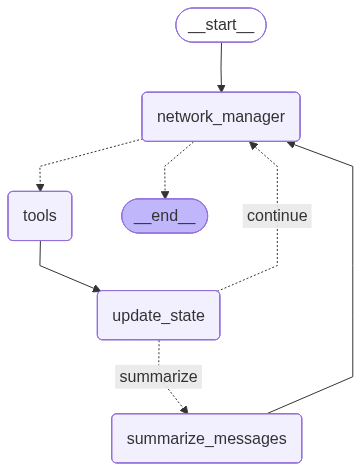

In [5]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## Run the Agent

In [6]:
import json
from datetime import datetime
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage


def run_agent_demo(agent, inputs: dict, config: dict):
    """Run the agent and stream output to console."""
    print("Starting Agent Execution...\n")

    for chunk in agent.stream(inputs, stream_mode="updates", config=config):
        for node_name, output in chunk.items():
            print(f"\n>>>> NODE: {node_name} <<<<")
            if node_name in ("network_manager", "tools"):
                if "messages" in output:
                    for m in output["messages"]:
                        print("   --- CURRENT CONTENT ---")
                        m.pretty_print()

                        if hasattr(m, 'tool_calls') and m.tool_calls:
                            print("   --- TOOL CALL ---")
                            for tc in m.tool_calls:
                                print(f"   -> {tc['name']}({json.dumps(tc['args'], default=str)})")

    # Save action log
    history = list(agent.get_state_history(config))
    history.reverse()

    last_message_id = None
    filename = f"react_agent_actions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

    with open(filename, "w", encoding="utf-8") as f:
        f.write("=== AGENT ACTION LOG ===\n\n")

        for i, state in enumerate(history):
            messages = state.values.get("messages", [])
            if not messages:
                continue

            m = messages[-1]

            if getattr(m, "id", None) == last_message_id:
                node_type = state.metadata.get("node", "update_state")
                if node_type in ("update_state", "summarize_messages"):
                    continue
                f.write(f"[STEP {i}] STATE UPDATE\n")
                f.write(f"  Node executed: {node_type}\n\n")
                continue

            last_message_id = getattr(m, "id", None)

            if isinstance(m, AIMessage) and m.tool_calls:
                f.write(f"[STEP {i}] AI -> TOOL CALL\n")
                for tc in m.tool_calls:
                    f.write(f"  -> {tc['name']}({json.dumps(tc['args'], default=str)})\n")
                f.write("\n")
                continue

            if isinstance(m, ToolMessage):
                content = m.content
                if isinstance(content, list):
                    content = " ".join(str(c) for c in content)
                f.write(f"[STEP {i}] TOOL RESULT ({m.name})\n")
                f.write(f"  {content.strip()}\n\n")
                continue

            if isinstance(m, AIMessage):
                content = m.content
                if isinstance(content, list):
                    content = " ".join(str(c) for c in content)
                if content.strip():
                    f.write(f"[STEP {i}] AI OUTPUT\n")
                    f.write(f"  {content.strip()}\n\n")
                continue

            if isinstance(m, HumanMessage):
                content = m.content
                if isinstance(content, list):
                    content = " ".join(str(c) for c in content)
                f.write(f"[STEP {i}] HUMAN INPUT\n")
                f.write(f"  {content.strip()}\n\n")
                continue

    print(f"\nExecution Complete. Detailed history saved to '{filename}'")

In [7]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content='''
Please add three high effectiveness hospitals to the network.
''')]

county_thresholds = {"wayne": 10.0}

inputs = {
    "messages": messages,
    "candidates": candidates,
    "members": members,
    "county_thresholds": county_thresholds
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- CURRENT CONTENT ---
================================== Ai Message ==================================
Tool Calls:
  get_candidate_schema (605866323)
 Call ID: 605866323
  Args:
   --- TOOL CALL ---
   -> get_candidate_schema({})

>>>> NODE: tools <<<<
   --- CURRENT CONTENT ---
================================= Tool Message =================================
Name: get_candidate_schema

{"id": "int64", "lat": "float64", "lon": "float64", "cluster": "str", "county": "str", "specialty": "str", "effectiveness": "int64"}

>>>> NODE: update_state <<<<

>>>> NODE: network_manager <<<<
   --- CURRENT CONTENT ---
================================== Ai Message ==================================
Tool Calls:
  get_candidates (935940087)
 Call ID: 935940087
  Args:
    specialty: hospital
    sort_by: effectiveness
    ascending: False
   --- TOOL CALL ---
   -> get_candidates({"specialty": "hospital", "sort_by": "effectiveness", "as

## Inspect Agent State

In [8]:
print("Original message:")
print(agent.get_state(config).values.get("original_message", ""))

Original message:

Please add three high effectiveness contract entities to the network.



In [9]:
print("Summary:")
print(agent.get_state(config).values.get("summary", ""))

Summary:



In [10]:
import pandas as pd
print("Current network:")
pd.DataFrame(agent.get_state(config).values.get("network", []))

Current network:


,id,lat,lon,cluster,county,specialty,effectiveness
0,14,42.007162,-83.407746,uniform,wayne,hospital,5
1,16,42.225273,-83.107177,uniform,wayne,hospital,5
2,8,42.303509,-83.198208,dearborn,wayne,hospital,5


## Try a More Complex Prompt

In [11]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
OK, now I'd like to add one more contract entity to the network. But I'd like to make sure this one has high effectiveness, but also one that best adds to the coverage. Find one, add it, and then report back on the status of the network.
''')]

inputs = {
    "messages": messages,
    # "candidates": candidates,
    # "members": members,
    # "county_thresholds": county_thresholds
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- CURRENT CONTENT ---
================================== Ai Message ==================================
Tool Calls:
  simulate_network_change (375647411)
 Call ID: 375647411
  Args:
    add_ids: []
    remove_ids: []
    compare_scenarios: [{'add_ids': [11]}, {'add_ids': [19]}]
   --- TOOL CALL ---
   -> simulate_network_change({"add_ids": [], "remove_ids": [], "compare_scenarios": [{"add_ids": [11]}, {"add_ids": [19]}]})

>>>> NODE: tools <<<<
   --- CURRENT CONTENT ---
================================= Tool Message =================================
Name: simulate_network_change

{"current": {"total_providers": 3, "coverage": [{"county": "wayne", "members_with_access": 1285, "total_members": 2000, "coverage_percentage": 64.25}]}, "scenarios": [{"add_ids": [19], "remove_ids": [], "total_providers": 4, "coverage": [{"county": "wayne", "members_with_access": 1837, "total_members": 2000, "coverage_percentage": 91.85}], "del

In [12]:
# Check final state
print("Summary:")
print(agent.get_state(config).values.get("summary", ""))

print("\nNetwork:")
pd.DataFrame(agent.get_state(config).values.get("network", []))

Summary:


Network:


,id,lat,lon,cluster,county,specialty,effectiveness
0,0,42.315277,-83.492023,canton,wayne,hospital,5
1,11,42.336226,-83.028018,detroit,wayne,hospital,5
2,9,42.406217,-83.386911,livonia,wayne,hospital,5
3,14,42.345358,-83.239483,uniform,wayne,hospital,5
